# SELENE: Sea Level Near-real time Quality Control Processing

This notebook demonstrates how to use SELENE for quality control of tide gauge data.
Based on the Design & User's Guide v1.0 by Puertos del Estado.


## 1. Environment Setup
SELENE works linked to a python virtual environment from which the code resolves the dependencies with external libraries used to manage and display data. 
The source package and environment manager used is conda.  
We will be using the python from the conda environment in this notebook to work with selene. (/opt/conda/envs/selene_training/bin/python)  
Outside this environment you would install selene with conda and run the scripts within an activated environment.  

### 1.1 install Selene environement

In [ ]:
!chmod +x ./setup.sh
!./setup.sh

### 1.2 Install and load python packages

In [6]:
import sys 
!{sys.executable} -m pip install utide python-dotenv numpy==1.24.3
print("\n✓ packages installed")


✓ packages installed


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import configparser
import sys
import logging
import warnings
import subprocess
import requests
import matplotlib.pyplot as plt
import utide
import os
import configuration.constants as c
import ipywidgets as widgets
import csv 
import pickle
import copy
from datetime import timedelta
from datetime import datetime
from dotenv import load_dotenv
from IPython.display import display, Image, JSON

print("\n✓ Imports succeeded")


✓ Imports succeeded


In [51]:
load_dotenv('./env')

True

## 2. Configuration Setup

### 2.1 Set up directory structure

SELENE is structured around four main sections/folders:  
* configuration: basic configuration files of the customization component 
* modules: main functional modules of SELENE, coded in Python. 
* utils: additional utilities and functionalities to support the modules. 
* datafiles : Input raw data files are stored in datafiles directory. 
* outputs:  outcomed files generated by SELENE are stored in the output directory.  

The main python command is selene.py. When run interactively, the output files can be visualized to check the quality control process with selenevis.py.  
Messages with information about processing steps and bad data detection can be followed on in selene.log (logs directory). 

In [52]:
# Define base paths (modify these according to your installation)
BASE_PATH = "./"  # Update this!
DATAFILES_PATH = os.path.join(BASE_PATH, "datafiles")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")
CONFIG_PATH = os.path.join(BASE_PATH, "configuration")

# Create directories if they don't exist
os.makedirs(DATAFILES_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(CONFIG_PATH, exist_ok=True)

print(f"Base path: {BASE_PATH}")
print(f"Datafiles path: {DATAFILES_PATH}")
print(f"Output path: {OUTPUT_PATH}")

Base path: ./
Datafiles path: ./datafiles
Output path: ./outputs


## 3. Example Run SELENE

![alt text](image-1.png)

### Role/function of the main modules of the software. 
##### QC MODULE (flagging data) 
* Format and date control 
* Out of range values 
* Algorithm for detection of spikes 
* Stability test: flagging values when there is no change in the magnitude of sea level after several time steps (stuck limit)  
##### INTERPOLATION MODULE (resampling and short gaps) 
* Adjusting and re-sampling of the time interval 
* Interpolation of very short gaps (smaller than 10–25 mins, depending on the tidal range) 
* Interpolation of wrong values previously flagged on the QC-module 
##### TIDE-SURGE MODULE 
* Computation of tide and residuals 
##### FILTER MODULE (hourly values) 
* Application of a filter to obtain hourly values

### 3.1 Execute SELENE Processing

Before launching SELENE, you need to create an entry for each of the stations you want to process in two files used as configuration resources : 
* A JSON file called stations.json (selene_training/configuration/stations.json). This file defines parameters (in the form of fields associated to each entry) that can be customized and defined independently for each station, to drive the computation of the different modules (setting thresholds, ranges and extra inputs), so you can adjust the values to refine the results. 
* A CSV file called code_guide.csv (selene_training/code_guide.csv). This file serves as a guide to define some information about the stations you want to process. For the scope of this version of SELENE, only the "code2" field is relevant, you can keep the rest of the fields with a generic content.
An important issue to consider is that the identifier of the entry you used in the station.json file has to match with the field “code2” you specify in code_guide.csv.

In [53]:
# Target station ID
with open(c.stationsfile) as f:
    stations = json.load(f)
TARGET_STATION = widgets.Dropdown(
    options=stations.keys(),
    description='Target Station:',
    disabled=False,
)

TARGET_STATION

Dropdown(description='Target Station:', options=('2059388', '6024460', '1000000', '1000001', 'abas', 'adak'), …

In [ ]:
# Run SELENE processing
print(f"Running SELENE for station {TARGET_STATION.value}...")
print("-" * 50)

!/opt/conda/envs/selene_training/bin/python selene.py {TARGET_STATION.value} 

Running SELENE for station abas...
--------------------------------------------------
/opt/conda/envs/selene_training/lib/python3.8/site-packages/utide/harmonics.py:16: RuntimeWarning: invalid value encountered in cast
  nshallow = np.ma.masked_invalid(const.nshallow).astype(int)
/opt/conda/envs/selene_training/lib/python3.8/site-packages/utide/harmonics.py:17: RuntimeWarning: invalid value encountered in cast
  ishallow = np.ma.masked_invalid(const.ishallow).astype(int) - 1
prep/calcs ... done.
/home/jovyan/work/selene_training/utils/utide_construct.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month_h['RES']=res_h
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... do

#### 3.1.2 Expected outcomes of selene.py launcher
If the execution of selene.py launcher runs succesfully a file named [code2]_original_sampling_flags.out will be created in "outputs" directory. This file will contain the original sampling data QC flagged  

### 3.2 Buddy Check Processing
The buddy check processing works over the QC flagged dataset generated by selene.py block, performing:
* Detection of furtherly bad data​ by
    * Comparation to nearby station data (if exists, in /outputs)​
    * Comparation to altimetry (if exists in /altimeter_data)​
* Detection of attenuated data​
* Hourly filtered data
* Tide / surge computation if harmonics available ​in /configuration/harmonics

In [ ]:
# Buddy check requires target year as last year of data
TARGET_YEAR = widgets.IntSlider(
    value=2025,
    min=2020,
    max=2026,
    step=1,
    description='TARGET YEAR:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

TARGET_YEAR

In [ ]:
print(f"Running buddy check for station {TARGET_STATION.value}, year {TARGET_YEAR.value}...")

!/opt/conda/envs/selene_training/bin/python buddy_check.py {TARGET_STATION.value} {TARGET_YEAR.value}

#### 3.2.2 Expected outcomes of buddy_check.py launcher
If the execution of buddy_check.py launcher runs succesfully several files will be produced in "outputs" directory:
* A file with original sampling data furtherly flagged => [code2]_original_sampling_buddy.out  
* A file recording hourly filtered data => [code2]_hourly_slev_buddy.out, 
* A file recording hourly residual data if harmonics are available for the station => [code2]_hourly_surge_buddy.out, 
* A file recording hourly tidal data if harmonics are available for the station => [code2]_hourly_tide_buddy.out

### 3.3 Visualization
Additionally, SELENE includes a visualization tool, selenevis.py, to validate and display the different products produced by selene.py and buddy_check.py blocks, and verify the correct performance and detection of wrong data.
In the current training version of SELENE, the tool creates and displays a combined view of all the products for a station generated by selene.py and buddy_check.py blocks : 
It must be invoked with arguments -station followed by the code of the station:  
python selenevis.py -station XXXXXXX

![alt text](image-2.png)

#### 3.3.1 Generate the graphs

In [ ]:
# Run SELENEVIS for visualization
print(f"Running SELENEVIS for station {TARGET_STATION.value}...")

!/opt/conda/envs/selene_training/bin/python selenevis.py -station {TARGET_STATION.value}

#### 3.3.2 Expected outcomes of buddy_check.py launcher
If the execution of selenevis.py launcher runs succesfully a PNG file will be produced in "outputs" directory: SELENEQC_graphics_Station_[code2].png



#### 3.3.3 Open the generated image

In [ ]:
with open(c.stationsfile) as f:
    stations = json.load(f)
    station_name = stations[TARGET_STATION.value]['name']
    
Image(filename=OUTPUT_PATH + "/SELENEQC_graphics_Station_" + station_name + ".png")

#### 3.3.4 View Output files for targeted station

In [ ]:
# List output files
print( OUTPUT_PATH)
output_files = []
if os.path.exists('./' + OUTPUT_PATH):
    output_files = os.listdir('./' + OUTPUT_PATH)
    
for file in sorted(output_files):
    if TARGET_STATION.value in file:
        filepath = os.path.join(OUTPUT_PATH, file)
        size = os.path.getsize(filepath)
        print(f"  - {file} ({size:,} bytes)")

## 4. Custom Data Integration

To add your own station data:

1. **Prepare data file**: Create ASCII .data file in `datafiles/`
2. **Update stations.json**: Add station configuration
3. **Update code_guide.csv** (if using): Add station metadata
4. **Run SELENE**: Execute with your station ID

## 4.1 Retrieve data from SLSMF

* Authentication:   
Go to our website and request an account [here](https://ioc-sealevelmonitoring.org/api.php).  
After your account has been approved you can request an api key [here](https://ioc-sealevelmonitoring.org/api.php).  
Place your api key in the env file, in accordance to the env.example file, or place copy it below.
* Documentation
Go to [api documentation](https://api.ioc-sealevelmonitoring.org/v2/doc), for a complete overview of our endpoints.  
If you wish to try out some enpoints use the api key you just created.  


### 4.1.1 Set API_KEY
store your api key in the ./env file or provide it below

In [10]:
print(os.getenv('API_KEY'))
APIKEY = widgets.Text(
    value=os.getenv('API_KEY'),
    placeholder='Type something',
    description='APIKEY:',
    disabled=False   
)
APIKEY

bd423717a30e8414189510b75eb36655049d3e1341d86b9b99e83eec2210534ea6f5bd4ecf37f447ec41588f12c1cb871bc6669dfaef758c213e6b522a078d47


Text(value='bd423717a30e8414189510b75eb36655049d3e1341d86b9b99e83eec2210534ea6f5bd4ecf37f447ec41588f12c1cb871b…

### 4.1.2 Download the Real Time data 
#### A. Set the basic api parameters 
used below to create all necessary output for SELENE

In [31]:
station = widgets.Text(
    value='abas',
    placeholder='IOC code',
    description='IOC:',
    disabled=False   
)
sensor = widgets.Text(
    value='rad',
    description='sensor type:',
    disabled=False   
)
timestart=widgets.DatePicker(
    description='timestart',
    disabled=False,
    value=datetime.strptime('01/01/2025', '%M/%d/%Y')
)
timestop=widgets.DatePicker(
    description='timestop',
    disabled=False,
    value=datetime.strptime('12/31/2025', '%M/%d/%Y')
)

from ipywidgets import Box

items = [station, sensor, timestart, timestop]
box = Box(children=items)

box

Box(children=(Text(value='abas', description='IOC:', placeholder='IOC code'), Text(value='rad', description='s…

#### B. Get station metadata 
metadata donwloaded from API, later used to create the config files for selene. 

In [62]:
url = "https://api.ioc-sealevelmonitoring.org/v2/stations/"+ station.value
querystring = {}
headers = {"X-API-KEY": os.getenv('API_KEY'), "accept": "aplication/json"}
response = requests.get(url, headers=headers, params=querystring)
station_metadata = json.loads(response.text)[0]
print(response.url)
from IPython.display import JSON
JSON(station_metadata, expanded=False)

https://api.ioc-sealevelmonitoring.org/v2/stations/abas


<IPython.core.display.JSON object>

#### C. Download realtime sea level data

In [27]:
if timestart.value and timestop.value: 
    loop_start = copy.deepcopy(timestart.value)
    output_file = DATAFILES_PATH + '/' + station.value + '.data' 
    if os.path.exists(output_file):
        os.remove(output_file)
        
    while (timestop.value - loop_start).total_seconds() > 0:
        timestop_parameter = loop_start + timedelta(days=30) 
        timestop_parameter = timestop.value if timestop_parameter > timestop.value else timestop_parameter
        url = "https://api.ioc-sealevelmonitoring.org/v2/stations/"+ station.value + "/data"
        querystring = {"timestart": loop_start.strftime("%Y-%m-%d"), "timestop": timestop_parameter, "includesensors[]": 'rad'  }
        headers = {"X-API-KEY": os.getenv('API_KEY'), "accept": "application/json"}
        response = requests.get(url, headers=headers, params=querystring)
        print(response.url)
        file = DATAFILES_PATH + '/' + station.value + '.data'
        with open(file, "a") as f:
            for entry in json.loads(response.text):
                slevel = float(entry['slevel'])*1000
                stime = entry['stime']
                f.write(f'{station.value} {stime} {slevel} 1\n')
        loop_start = timestop_parameter
    print("\n Download complete, data stored at " + file)
else:
    print("\nPlease provide timestart and timestop in the cell above. ")

https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-01-01&timestop=2025-01-31&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-01-31&timestop=2025-03-02&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-03-02&timestop=2025-04-01&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-04-01&timestop=2025-05-01&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-05-01&timestop=2025-05-31&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-05-31&timestop=2025-06-30&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-06-30&timestop=2025-07-30&includesensors%5B%5D=rad
https://api.ioc-sealevelmonitoring.org/v2/stations/abas/data?timestart=2025-07-30&timestop=2025-08-29&includese

## 4.2 run U-tide 
create coeffs per year as needed for SELENE.
Data is stored as pickle in configuration/harmonics/<station.value>_harm_all.pkl.
### 4.2.1 convert realtime data to object for utide

In [78]:
names = ["station", "date", "time", "value", "flag"]

obs = pd.read_csv(
    DATAFILES_PATH + '/' + station.value + '.data',
    names=names,
    skipinitialspace=True,
    sep='\s+',    
    na_values="9.999",
)

obs["anomaly"] = (obs["value"])/1000
index = pd.to_datetime(obs["date"] + ' ' + obs['time'])
obs.index = index
obs.dropna(subset=["value", "anomaly"], inplace=True)
mean = obs["value"].mean()
obs.head(5)


,station,date,time,value,flag,anomaly
2025-01-01 00:01:00,abas,2025-01-01,00:01:00,2286.0,1,2.2860
2025-01-01 00:02:00,abas,2025-01-01,00:02:00,2276.9,1,2.2769
2025-01-01 00:03:00,abas,2025-01-01,00:03:00,2286.0,1,2.2860
2025-01-01 00:04:00,abas,2025-01-01,00:04:00,2301.2,1,2.3012
2025-01-01 00:05:00,abas,2025-01-01,00:05:00,2292.1,1,2.2921


### 4.2.2 run utide

In [79]:

import datetime as dt
print(f'calculating for station {station.value}')
years = list({i for i in obs.index.year})
coeffs = {}
for year in years: 
    include = obs[obs.index.year == year]
    years = list({i for i in include.index.year})
    print(f'calculating coefs for {year}')
    print(datetime.now())
    coef = utide.solve(
        include.index,
        include["anomaly"],
        lat=station_metadata['Lat'],
        method="ols",
        conf_int="MC",
        verbose=False
    )
    coeffs[str(year)] = coef
    print(datetime.now())

with open(f'{CONFIG_PATH}/harmonics/{station.value}_harm_all.pkl', 'wb') as handle:
    pickle.dump(coeffs, handle, protocol=pickle.HIGHEST_PROTOCOL)



calculating for station abas
calculating coefs for 2025
2026-05-11 14:54:20.601708
2026-05-11 14:55:18.792076


### 4.2.3 Pickle is dumped as txt file for you to see it's content. 

In [39]:

def to_serializable(obj):

    if isinstance(obj, dict):
        return {key: to_serializable(value) for key, value in obj.items()}

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, (list, tuple)):
        return [to_serializable(value) for value in obj]

    return obj


output_txt = "oce2utide_coef.txt"

coeffs_str = {}

for  key in coeffs.keys():
    coeffs_str[key] = to_serializable(coeffs[key]),


with open(f'{CONFIG_PATH}/harmonics/{station.value}_harm_all.txt', "w") as f:
    json.dump(
        coeffs_str,
        f,
        indent=4,
    )

### 4.2.4 visualize data, prediction and residuals. 

dict_keys(['t_in', 'epoch', 'constit', 'min_SNR', 'min_PE', 't_mpl', 'h'])


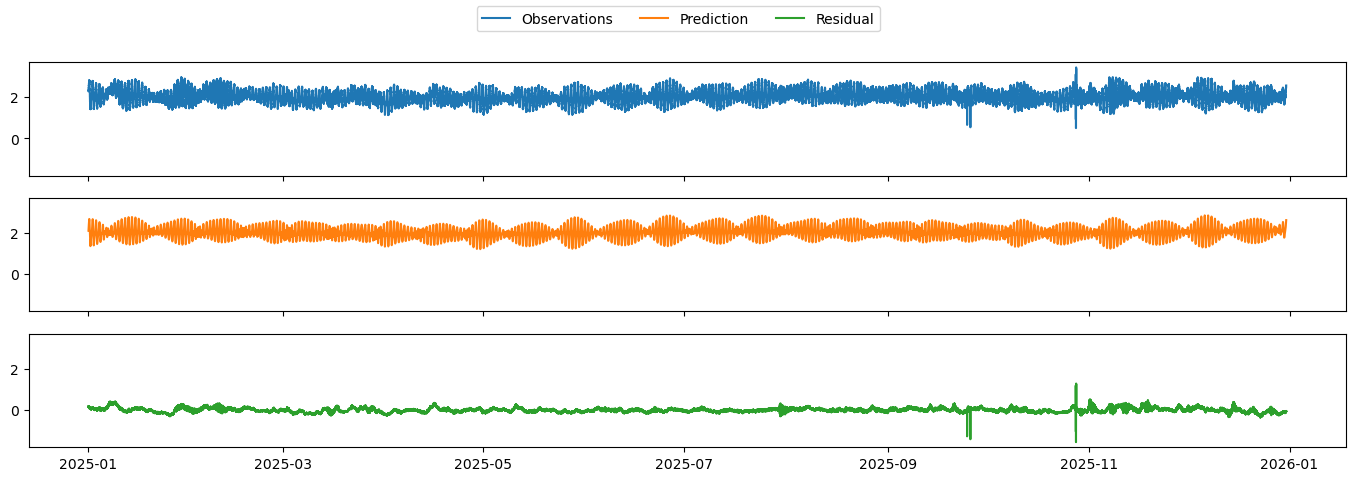

In [80]:
tide = utide.reconstruct(obs.index, coef, verbose=False)
print(tide.keys())
t = obs.index.to_pydatetime()

fig, (ax0, ax1, ax2) = plt.subplots(figsize=(17, 5), nrows=3, sharey=True, sharex=True)

ax0.plot(t, obs.anomaly, label="Observations", color="C0")
ax1.plot(t, tide.h, label="Prediction", color="C1")

ax2.plot(t, obs.anomaly - tide.h, label="Residual", color="C2")

fig.legend(ncol=3, loc="upper center");

## 4.3 Add config for Selene 



### 4.3.1 stations.json

In [ ]:
# Load existing configuration
with open(c.stationsfile, 'r') as f:
    stations = json.load(f)

# Add new station
stations[station_metadata['Code']] = {
    "foremanharmfile": f"configuration/harmonics/{station.value}_harm.pkl",
    "latitude": station_metadata['Lat'],
    "longitude": station_metadata['Lon'],
    "minint": 60,
    "maxlevel": 18406,
    "maxsurge": 13497,
    "minlevel": -8588,
    "minsurge": -13497,
    "max": 2300,
    "qc_level_nsigma": 3,
    "qc_level_splinedegree": 2,
    "qc_level_winsize": 40,
    "qc_stucklimit": 10,
    "qc_surge_nsigma": 5,
    "qc_surge_splinedegree": 3,
    "qc_surge_winsize": 80,
    "shortname": station_metadata['Code'].upper(),
    "name": station_metadata['Code'],
    "seriesdatecolumns": "1,2",
    "seriesdateformat": "%Y-%m-%d%H:%M:%S",
    "seriesfile": f"datafiles/{station.value + '.data'}",
    "seriesqccolumn": 4,
    "seriesseparator": " ",
    "seriesvaluecolumn": 3,
    "data_mode": "R",
    }

# Save updated configuration
with open(c.stationsfile, 'w') as f:
    json.dump(stations, f, indent=4)


print(f"✓ Added station {station_metadata['Code']}")

display(JSON(c.stationsfile, expanded=False))


### 4.3.2 code_guide.csv

In [63]:
    """Append a new station entry to code_guide.csv"""
    new_row = {
        'filename': 'XX_XX_XX_' + station.value + '.nc',
        'leader': 'XX',
        'region': 'XX',
        '#ID': station.value,
        'code2': station.value,
        'lon': station_metadata['Lon'],
        'lat': station_metadata['Lat'],
        'sampling': 'one_sampling'
    }
    
    fieldnames = ['filename', 'leader', 'region', '#ID', 'code2', 'lon', 'lat', 'sampling']
    
    with open('code_guide.csv', 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter=';')
        writer.writerow(new_row)
        

## 4.4 Run Selene
Rerun part 3 of this notebook for the added station. 